# Avance 3 – Baseline
## Proyecto Integrador – Equipo 22

Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

### Modelo baseline para clasificación multiclase de cáncer colorrectal mediante biomarcadores lipidómicos y metabolómicos


# 1. Objetivo del baseline

El objetivo de esta fase es construir un modelo baseline capaz de discriminar entre los grupos clínicos CTRL, AA y CRC utilizando biomarcadores lipidómicos y metabolómicos previamente seleccionados.

El baseline permitirá:
- evaluar la viabilidad predictiva del problema,
- establecer un punto de referencia para modelos futuros,
- analizar la relevancia de las características,
- e identificar posibles signos de subajuste o sobreajuste.

Dado el enfoque interpretativo del proyecto, se priorizaron modelos supervisados con alta interpretabilidad y bajo riesgo de sobreajuste.

In [43]:
# ============================================================
# Librerías
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler

Con base en la retroalimentación recibida durante la fase de ingeniería de características, se redujo el espacio de variables para evitar redundancia biológica y sobreingeniería.

El dataset final utilizado para el baseline incluye:
- biomarcadores robustos comunes entre ANOVA y Mutual Information,
- variables clínicas relevantes,
- y variables categóricas seleccionadas.

No se incluyeron:
- componentes PCA,
- variables derivadas redundantes,
- ni múltiples niveles simultáneos de agregación biológica.

In [44]:
# 2. Carga del dataset final

# ============================================================
#  Montar Google Drive y definir ruta del dataset
# ============================================================
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

DATA_PATH = '/content/drive/MyDrive/Proyecto Integrador/'
file_path = DATA_PATH + 'Avance3_dataset_final_selected_raw.csv'

print('Ruta del archivo:', file_path)

Mounted at /content/drive
Ruta del archivo: /content/drive/MyDrive/Proyecto Integrador/Avance3_dataset_final_selected_raw.csv


In [45]:
# ============================================================
# Cargar dataset final
# ============================================================

data = pd.read_csv(
    file_path,
    encoding='latin1'
)

print("Dimensiones:", data.shape)

data.head()

Dimensiones: (211, 17)


,group,age,fit_ug_g,gender,fob,TG(51:4),CE(20:5),PC(O-16:0/16:0),SM(42:3),SM(33:1),PC(O-16:0/18:2),GlcCer(d18:1/24:0),PC(36:5),SM(d18:1/24:1) + SM(d18:2/24:0),SM(d18:1/23:0),PC(O-34:1),SM(d18:1/22:0)
0,CRC,77,19,Male,NO,0.049500,0.016553,0.612773,0.078290,0.154913,0.079365,0.097677,0.000629,0.129482,0.026339,0.249556,0.032637
1,CTRL,82,1001,Female,YES,NaN,0.007331,0.011522,0.000792,0.016999,0.076283,0.037884,NaN,0.001600,0.000958,0.011825,0.001046
2,CRC,63,1001,Male,YES,0.012213,0.009443,0.025959,0.001104,NaN,0.004263,0.041985,0.000190,0.001524,NaN,0.006337,0.000333
3,CRC,87,1001,Male,YES,0.039126,0.054523,0.023735,0.001329,0.005501,0.015591,0.029539,0.001683,0.002492,0.000906,0.016361,0.000714
4,CTRL,73,19,Female,NO,0.046892,NaN,0.009139,NaN,0.001846,0.003925,NaN,NaN,NaN,NaN,0.002376,0.000213


In [46]:
# ============================================================
# Información general del dataset
# ============================================================

print("Número de muestras:", data.shape[0])

print("Número total de variables predictoras:", data.shape[1] - 1)

print("Variables clínicas:")
print(['age', 'fit_ug_g'])

print("Variables categóricas:")
print(categorical_cols)

print("Número de biomarcadores lipidómicos/metabolómicos:",
      len(data.columns) - 1 - 2 - 2)

Número de muestras: 211
Número total de variables predictoras: 16
Variables clínicas:
['age', 'fit_ug_g']
Variables categóricas:
['gender', 'fob']
Número de biomarcadores lipidómicos/metabolómicos: 12


# 3. Preprocesamiento para modelado

El dataset final aún contiene valores faltantes asociados al comportamiento natural de datos metabolómicos.

Para preparar los datos para el baseline:
- las variables numéricas serán imputadas mediante mediana,
- las variables categóricas mediante moda,
- las variables categóricas serán codificadas,
- y las variables numéricas serán escaladas mediante estandarización.

Estas decisiones buscan:
- reducir sensibilidad a valores extremos,
- mejorar convergencia del modelo,
- y preservar interpretabilidad.

In [47]:
# ============================================================
# Separación de variables
# ============================================================

target = 'group'

categorical_cols = ['gender', 'fob']

numeric_cols = [
    col for col in data.columns
    if col not in categorical_cols + [target]
]

X = data.drop(columns=[target])

y = data[target]

print("Variables numéricas:", len(numeric_cols))
print("Variables categóricas:", len(categorical_cols))

Variables numéricas: 14
Variables categóricas: 2


In [48]:
# ============================================================
# Imputación de missing values
# ============================================================

from sklearn.impute import SimpleImputer

# Numéricas
num_imputer = SimpleImputer(strategy='median')

X[numeric_cols] = num_imputer.fit_transform(
    X[numeric_cols]
)

# Categóricas
cat_imputer = SimpleImputer(strategy='most_frequent')

X[categorical_cols] = cat_imputer.fit_transform(
    X[categorical_cols]
)

X.isna().sum().sum()

np.int64(0)

In [49]:
# ============================================================
# Codificación categórica
# ============================================================

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X.head()

,age,fit_ug_g,TG(51:4),CE(20:5),PC(O-16:0/16:0),SM(42:3),SM(33:1),PC(O-16:0/18:2),GlcCer(d18:1/24:0),PC(36:5),SM(d18:1/24:1) + SM(d18:2/24:0),SM(d18:1/23:0),PC(O-34:1),SM(d18:1/22:0),gender_Male,fob_YES
0,77.0,19.0,0.049500,0.016553,0.612773,0.078290,0.154913,0.079365,0.097677,0.000629,0.129482,0.026339,0.249556,0.032637,True,False
1,82.0,1001.0,0.044337,0.007331,0.011522,0.000792,0.016999,0.076283,0.037884,0.000541,0.001600,0.000958,0.011825,0.001046,False,True
2,63.0,1001.0,0.012213,0.009443,0.025959,0.001104,0.005131,0.004263,0.041985,0.000190,0.001524,0.000970,0.006337,0.000333,True,True
3,87.0,1001.0,0.039126,0.054523,0.023735,0.001329,0.005501,0.015591,0.029539,0.001683,0.002492,0.000906,0.016361,0.000714,True,True
4,73.0,19.0,0.046892,0.008259,0.009139,0.001078,0.001846,0.003925,0.031384,0.000541,0.001314,0.000970,0.002376,0.000213,False,False


In [50]:
# ============================================================
# Escalamiento
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_scaled.head()

,age,fit_ug_g,TG(51:4),CE(20:5),PC(O-16:0/16:0),SM(42:3),SM(33:1),PC(O-16:0/18:2),GlcCer(d18:1/24:0),PC(36:5),SM(d18:1/24:1) + SM(d18:2/24:0),SM(d18:1/23:0),PC(O-34:1),SM(d18:1/22:0),gender_Male,fob_YES
0,0.229301,-0.791246,-0.235302,0.056970,7.258593,9.419051,9.356431,1.662522,0.951144,-0.163842,10.176721,4.542744,5.390075,6.442164,0.789352,-1.205607
1,0.614511,1.519928,-0.252008,-0.281257,-0.252800,-0.271420,0.481152,1.583363,-0.185970,-0.191217,-0.242691,-0.264352,-0.067958,-0.253691,-1.266862,0.829458
2,-0.849289,1.519928,-0.355958,-0.203798,-0.072450,-0.232434,-0.282599,-0.266729,-0.107986,-0.300962,-0.248874,-0.262131,-0.193958,-0.404683,0.789352,0.829458
3,0.999722,1.519928,-0.268870,1.449525,-0.100231,-0.204366,-0.258788,0.024268,-0.344665,0.166259,-0.170019,-0.274079,0.036176,-0.323866,0.789352,0.829458
4,-0.078868,-0.791246,-0.243743,-0.247228,-0.282569,-0.235698,-0.494034,-0.275393,-0.309582,-0.191217,-0.266008,-0.262131,-0.284891,-0.430210,-1.266862,-1.205607


# 4. Selección del algoritmo baseline

Se seleccionó Regresión Logística Multiclase como modelo baseline debido a que:

- el conjunto de datos es tabular y relativamente pequeño,
- el número de muestras es limitado respecto al número de variables,
- el problema corresponde a clasificación multiclase supervisada,
- y el proyecto prioriza interpretabilidad biomédica sobre complejidad algorítmica.

La regresión logística permite:
- interpretar coeficientes,
- analizar importancia relativa de biomarcadores,
- reducir riesgo de sobreajuste,
- y establecer una referencia clara para modelos más complejos en etapas posteriores.

Además, es ampliamente utilizada como baseline en problemas biomédicos debido a su estabilidad y facilidad de interpretación.

# 5. Métricas de evaluación

Dado que el problema corresponde a clasificación multiclase y existe posible desbalance entre grupos clínicos, se seleccionó Macro F1-score como métrica principal.

Esta métrica:
- considera simultáneamente precisión y recall,
- da igual importancia a todas las clases,
- y evita que clases dominantes influyan excesivamente en la evaluación global.

Adicionalmente se analizaron:
- accuracy,
- precision macro,
- recall macro,
- y matrices de confusión.

In [51]:
# ============================================================
# Verificación de distribución de clases
# ============================================================

class_distribution = y.value_counts().to_frame(name='n')
class_distribution['proportion'] = y.value_counts(normalize=True)

class_distribution

,n,proportion
group,,
CTRL,78,0.369668
CRC,75,0.355450
AA,58,0.274882


In [52]:
# ============================================================
# Métrica principal seleccionada
# ============================================================

primary_metric = 'f1_macro'

print(f"Métrica principal seleccionada: {primary_metric}")

Métrica principal seleccionada: f1_macro


# 6. Desempeño mínimo esperado

Dado que el problema incluye tres clases clínicas (CTRL, AA y CRC), un clasificador aleatorio tendría un desempeño esperado cercano al 33%.

Por ello, se consideró que un baseline útil debería superar claramente dicho valor y mostrar capacidad discriminativa consistente entre clases.

In [53]:
# ============================================================
# Baseline aleatorio esperado
# ============================================================

n_classes = y.nunique()
random_baseline = 1 / n_classes

print(f"Número de clases: {n_classes}")
print(f"Desempeño esperado por azar: {random_baseline:.3f}")

Número de clases: 3
Desempeño esperado por azar: 0.333


# 7. Validación cruzada estratificada

Se utilizó validación cruzada estratificada para preservar la proporción de clases en cada fold y reducir la varianza de la evaluación dada la cantidad limitada de muestras.

In [54]:
# ============================================================
# Validación cruzada
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = LogisticRegression(
    max_iter=5000,
    multi_class='multinomial',
    random_state=42
)

scoring = [
    'accuracy',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]

cv_results = cross_validate(
    model,
    X_scaled,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

results = pd.DataFrame(cv_results)

results.head()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

,fit_time,score_time,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_f1_macro,train_f1_macro
0,0.016543,0.014572,0.581395,0.678571,0.569444,0.659366,0.569444,0.658189,0.569444,0.655714
1,0.009927,0.011507,0.571429,0.715976,0.543727,0.703305,0.547601,0.701857,0.541671,0.701607
2,0.013503,0.011671,0.714286,0.668639,0.702381,0.657078,0.698485,0.652803,0.698644,0.651937
3,0.009676,0.011607,0.523810,0.739645,0.508712,0.729316,0.511111,0.726075,0.509490,0.726617
4,0.009834,0.011553,0.666667,0.686391,0.656349,0.674223,0.638889,0.672061,0.616452,0.672264


In [55]:
# ============================================================
# Resultados promedio
# ============================================================

summary_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision Macro',
        'Recall Macro',
        'F1 Macro'
    ],
    'Train Mean': [
        results['train_accuracy'].mean(),
        results['train_precision_macro'].mean(),
        results['train_recall_macro'].mean(),
        results['train_f1_macro'].mean()
    ],
    'Validation Mean': [
        results['test_accuracy'].mean(),
        results['test_precision_macro'].mean(),
        results['test_recall_macro'].mean(),
        results['test_f1_macro'].mean()
    ]
})

summary_results

,Metric,Train Mean,Validation Mean
0,Accuracy,0.697844,0.611517
1,Precision Macro,0.684658,0.596123
2,Recall Macro,0.682197,0.593106
3,F1 Macro,0.681628,0.587140


La diferencia observada entre métricas de entrenamiento y validación fue moderada, lo que sugiere que el modelo mantiene una capacidad razonable de generalización sin evidencias fuertes de sobreajuste.

Además, el desempeño de validación superó claramente el baseline aleatorio esperado para un problema multiclase de tres categorías.

In [56]:
# ============================================================
# Comparación contra desempeño mínimo esperado
# ============================================================

baseline_f1 = summary_results.loc[
    summary_results['Metric'] == 'F1 Macro',
    'Validation Mean'
].values[0]

print(f"Macro F1 del baseline: {baseline_f1:.3f}")
print(f"Desempeño mínimo esperado por azar: {random_baseline:.3f}")

if baseline_f1 > random_baseline:
    print("El modelo baseline supera el desempeño esperado por azar.")
else:
    print("El modelo baseline NO supera el desempeño esperado por azar.")

Macro F1 del baseline: 0.587
Desempeño mínimo esperado por azar: 0.333
El modelo baseline supera el desempeño esperado por azar.


# 8. Evaluación de sub/sobreajuste

Se compararon las métricas obtenidas en entrenamiento y validación para identificar posibles signos de subajuste o sobreajuste.

Diferencias excesivas entre ambos conjuntos podrían indicar sobreajuste, mientras que desempeños bajos en ambos podrían sugerir subajuste.

In [57]:
# ============================================================
# Diagnóstico simple de sub/sobreajuste
# ============================================================

train_f1 = summary_results.loc[
    summary_results['Metric'] == 'F1 Macro',
    'Train Mean'
].values[0]

val_f1 = summary_results.loc[
    summary_results['Metric'] == 'F1 Macro',
    'Validation Mean'
].values[0]

gap = train_f1 - val_f1

print(f"F1 Macro entrenamiento: {train_f1:.3f}")
print(f"F1 Macro validación: {val_f1:.3f}")
print(f"Diferencia train-validation: {gap:.3f}")

if gap > 0.15:
    print("Posible sobreajuste: el desempeño en entrenamiento es considerablemente mayor que en validación.")
elif train_f1 < 0.40 and val_f1 < 0.40:
    print("Posible subajuste: el desempeño es bajo tanto en entrenamiento como en validación.")
else:
    print("No se observan signos fuertes de subajuste o sobreajuste.")

F1 Macro entrenamiento: 0.682
F1 Macro validación: 0.587
Diferencia train-validation: 0.094
No se observan signos fuertes de subajuste o sobreajuste.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

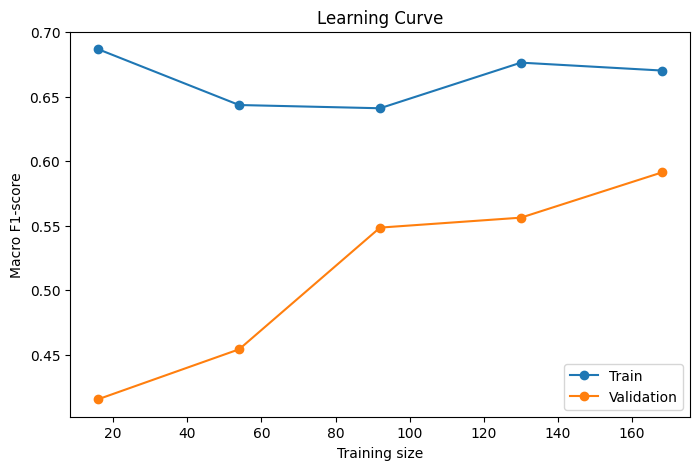

In [58]:
# ============================================================
# Curva de aprendizaje
# ============================================================

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_scaled,
    y,
    cv=cv,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label='Train')
plt.plot(train_sizes, test_mean, marker='o', label='Validation')

plt.xlabel('Training size')
plt.ylabel('Macro F1-score')

plt.title('Learning Curve')

plt.legend()

plt.show()

# 9. Importancia de características

Debido a la naturaleza interpretable de la regresión logística, los coeficientes del modelo permiten analizar la contribución relativa de los biomarcadores en la clasificación multiclase.

In [59]:
# ============================================================
# Entrenamiento final
# ============================================================

model.fit(X_scaled, y)

coef_df = pd.DataFrame(
    model.coef_.T,
    index=X_scaled.columns,
    columns=model.classes_
)

coef_df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,AA,CRC,CTRL
age,0.194604,0.324537,-0.519141
fit_ug_g,-0.255086,0.643836,-0.388750
TG(51:4),0.016803,-0.021783,0.004980
CE(20:5),0.225660,0.371956,-0.597616
PC(O-16:0/16:0),-0.386676,0.118098,0.268578


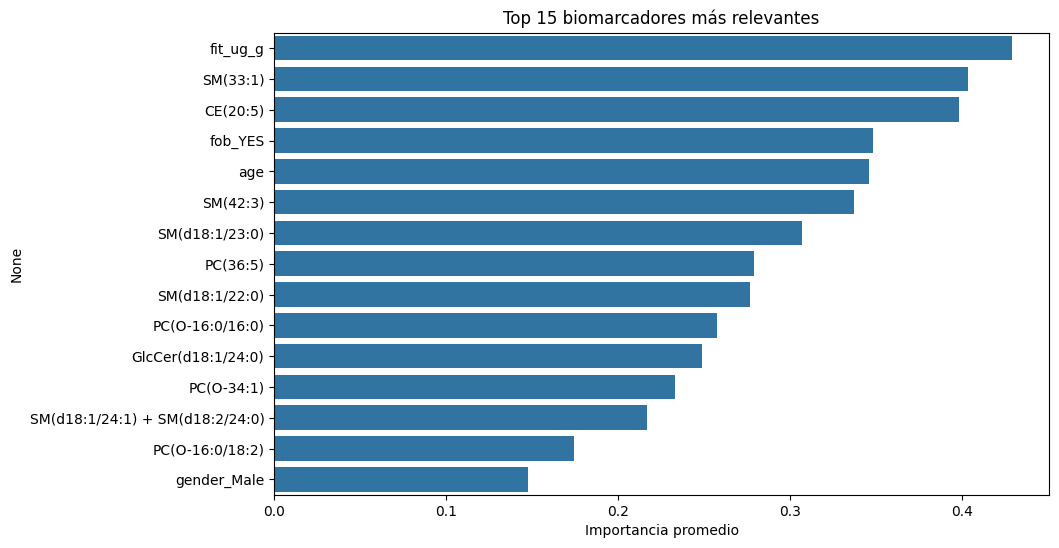

In [60]:
# ============================================================
# Importancia promedio
# ============================================================

importance = coef_df.abs().mean(axis=1)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.values[:15],
    y=importance.index[:15]
)

plt.title("Top 15 biomarcadores más relevantes")

plt.xlabel("Importancia promedio")

plt.show()

In [61]:
# ============================================================
# Tabla de importancia de características
# ============================================================

feature_importance_table = pd.DataFrame({
    'feature': importance.index,
    'importance_mean_abs_coef': importance.values
})

feature_importance_table.head(15)

,feature,importance_mean_abs_coef
0,fit_ug_g,0.429224
1,SM(33:1),0.403503
2,CE(20:5),0.398410
3,fob_YES,0.348027
4,age,0.346094
5,SM(42:3),0.337439
6,SM(d18:1/23:0),0.307148
7,PC(36:5),0.278891
8,SM(d18:1/22:0),0.276880
9,PC(O-16:0/16:0),0.257784


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

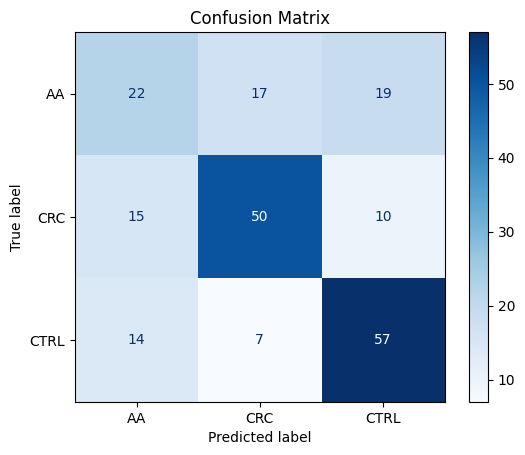

In [62]:
# ============================================================
# Matriz de confusión
# ============================================================

from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    model,
    X_scaled,
    y,
    cv=cv
)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

In [63]:
# ============================================================
# Reporte de clasificación
# ============================================================

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

          AA       0.43      0.38      0.40        58
         CRC       0.68      0.67      0.67        75
        CTRL       0.66      0.73      0.70        78

    accuracy                           0.61       211
   macro avg       0.59      0.59      0.59       211
weighted avg       0.60      0.61      0.61       211



# 10. Interpretación preliminar

El modelo baseline obtuvo un Macro F1-score de validación superior al desempeño esperado por azar, lo que indica que los biomarcadores seleccionados contienen señal discriminativa para diferenciar entre CTRL, AA y CRC.

La matriz de confusión permite observar en qué clases el modelo presenta mayor o menor capacidad de discriminación. Esto es importante porque, en un contexto biomédico, no basta con evaluar el desempeño global; también es necesario revisar si existen errores sistemáticos entre grupos clínicamente relevantes.

La clase AA presentó menor desempeño relativo, lo cual sugiere que la discriminación entre adenoma avanzado y los otros grupos clínicos podría ser más compleja. Este resultado es relevante para etapas posteriores, donde modelos más flexibles podrían explorar patrones no lineales sin perder interpretabilidad.

El análisis de coeficientes de la regresión logística permitió identificar las variables con mayor contribución promedio al modelo. Dado que el dataset final fue reducido a biomarcadores robustos comunes entre ANOVA y Mutual Information, la importancia observada se interpreta como una señal preliminar de relevancia predictiva, no como evidencia causal.

En conjunto, el baseline muestra viabilidad predictiva y ofrece una referencia interpretable para comparar modelos más complejos en avances posteriores.

# 11. Conclusiones

El modelo baseline basado en Regresión Logística Multiclase permitió establecer un punto de referencia interpretable para la clasificación de grupos clínicos utilizando biomarcadores lipidómicos y metabolómicos.

Los resultados obtenidos mostraron un desempeño superior al esperado por azar, sugiriendo que el dataset contiene información discriminativa relevante para el problema planteado.

La validación cruzada estratificada permitió evaluar estabilidad y generalización, mientras que el análisis de coeficientes facilitó identificar biomarcadores con posible relevancia biológica.

En conjunto, este baseline proporciona una referencia sólida para comparar modelos más complejos en etapas posteriores del proyecto dentro del marco metodológico CRISP-ML(Q).

El baseline obtuvo un Macro F1-score de validación de 0.587, superando el desempeño esperado por azar de 0.333 para un problema de tres clases.

Estos resultados respaldan la viabilidad del problema de clasificación multiclase mediante biomarcadores metabolómicos y lipidómicos, justificando la exploración posterior de modelos alternativos y estrategias de optimización en las siguientes fases del proyecto.

El baseline desarrollado establece una referencia metodológica interpretable y reproducible para evaluar posteriormente modelos más complejos, permitiendo comparar mejoras predictivas sin perder trazabilidad biológica ni explicabilidad clínica.

# 12. Referencias

- Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O’Reilly Media.

- Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). CRISP-ML(Q): The ML Lifecycle Process.

- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python.